In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import random
import matplotlib.pyplot as plt
from skimage.util import random_noise
from tensorflow.keras.layers import Layer, Conv2D, Add, ReLU, Concatenate, GlobalAveragePooling2D, Multiply, Input, Lambda,  MaxPooling2D, UpSampling2D, BatchNormalization, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.models import load_model
from tensorflow.keras.saving import register_keras_serializable


In [2]:

def preprocess(sample, img_size):
    """Preprocessa le immagini: ridimensionamento e normalizzazione."""
    image = tf.image.resize(sample['image'], img_size) / 255.0  # Normalizza in [0,1]
    label = sample['label']  # Estrai l'etichetta
    return image, label

def load_dataset(split, img_size=(256,256), batch_size=16):
    """
    Carica il dataset Oxford-IIIT Pet da tfds e applica il preprocessamento.
    Ritorna un dataset in batch.
    split: 'train[:80%]' 'train[80%:]' 'test'
    """

    print(split)
    dataset = tfds.load('oxford_iiit_pet', split=split, as_supervised=False)  # as_supervised=False per mantenere dict
    dataset = dataset.map(lambda sample: preprocess(sample, img_size))  # Preprocessing
    dataset = dataset.shuffle(1024).batch(batch_size).prefetch(tf.data.AUTOTUNE)  # Ottimizza il caricamento
    return dataset



In [3]:
# Parametri
size = 128
img_size = (size, size)
batch_size = 64
noise_factor = 0.3
epochs = 20

# Caricamento dataset
train_ds = load_dataset( split='train[:80%]', img_size=img_size, batch_size=batch_size)
valid_ds = load_dataset( split='train[80%:]', img_size=img_size, batch_size=batch_size)
test_ds  = load_dataset( split='test',        img_size=img_size, batch_size=batch_size)

train[:80%]


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.JHYH1Y_4.0.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.JHYH1Y_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
train[80%:]
test


In [4]:
"""def add_noise(x, noise_factor=0.1):
    noise = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=1.0)
    x_noisy = x + noise_factor * noise
    #x_noisy = tf.clip_by_value(x_noisy, 0.0, 0.1)
    return x_noisy"""

def add_noise_2(x, noise_factor=0.1):
    noise = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=noise_factor)
    x_noisy = x + noise
    x_noisy = tf.clip_by_value(x_noisy, 0.0, 1.0)
    return x_noisy

def add_noise(x):
    noise_levels = [0.1, 0.2, 0.3, 0.4]
    noise_factor = tf.random.shuffle(noise_levels)[0]  # scegli uno random tra i 4
    noise = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=noise_factor)
    x_noisy = x + noise
    x_noisy = tf.clip_by_value(x_noisy, 0.0, 1.0)
    return x_noisy

In [5]:
def add_fixed_noise(x, noise_factor):
    noise = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=noise_factor)
    x_noisy = x + noise
    x_noisy = tf.clip_by_value(x_noisy, 0.0, 1.0)
    return x_noisy

def add_noise_balanced(dataset, noise_levels=[0.1, 0.2, 0.3, 0.4]):
    # Calcola la lunghezza del dataset
    dataset_size = 0
    for _ in dataset:
        dataset_size += 1

    subset_size = dataset_size // len(noise_levels)

    # Dividi il dataset in sottoinsiemi uguali
    subsets = []
    for i in range(len(noise_levels)):
        start = i * subset_size
        end = start + subset_size if i != len(noise_levels)-1 else dataset_size
        subset = dataset.skip(start).take(end - start)
        subsets.append(subset)

    # Applica il rumore fisso a ogni sottoinsieme
    noisy_subsets = []
    for noise_factor, subset in zip(noise_levels, subsets):
        noisy_subset = subset.map(lambda x, label: (add_fixed_noise(x, noise_factor), x))
        noisy_subsets.append(noisy_subset)

    # Combina i sottoinsiemi rumorosi
    balanced_noisy_dataset = noisy_subsets[0]
    for s in noisy_subsets[1:]:
        balanced_noisy_dataset = balanced_noisy_dataset.concatenate(s)

    # Mescola per evitare ordini troppo rigidi
    balanced_noisy_dataset = balanced_noisy_dataset.shuffle(buffer_size=1024)

    return balanced_noisy_dataset

In [6]:
train_ds_noisy = add_noise_balanced(train_ds)
valid_ds_noisy = add_noise_balanced(valid_ds)

In [7]:
def plot_side_by_side(x_noisy, x_original, n=10):
    """
    Visualizza n coppie di immagini affiancando l'immagine rumorosa e quella originale per immagini a colori.
    """
    plt.figure(figsize=(20, 4))
    for i in range(n):
        # Immagine rumorosa
        ax = plt.subplot(2, n, i+1)
        plt.imshow(x_noisy[i])
        plt.title("Rumorosa")
        plt.axis('off')

        # Immagine originale
        ax = plt.subplot(2, n, i+1+n)
        plt.imshow(x_original[i])
        plt.title("Originale")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

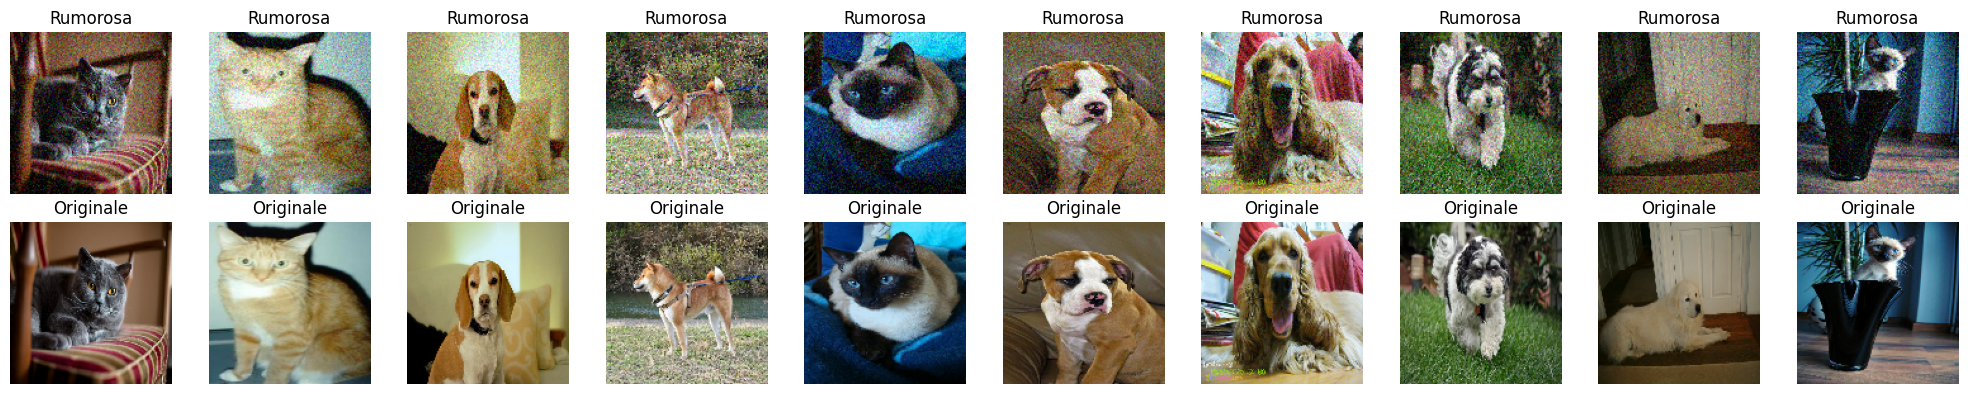

In [8]:
# Prendi un batch dal dataset (ad esempio, il primo batch)
batch = next(iter(train_ds_noisy))
x_noisy_batch, x_original_batch = batch

# Converti i tensori in array NumPy
x_noisy_np = x_noisy_batch.numpy()
x_original_np = x_original_batch.numpy()

# Usa la funzione plot_side_by_side per visualizzare n immagini
plot_side_by_side(x_noisy_np, x_original_np, n=10)


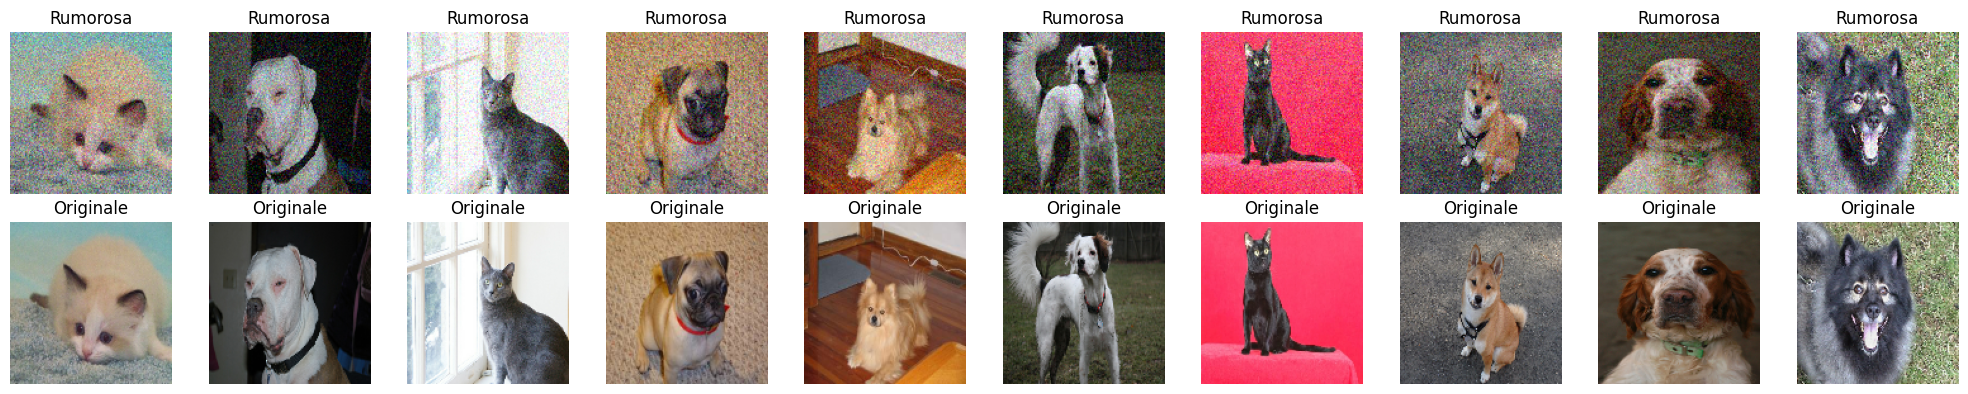

In [9]:
# Prendi un batch dal dataset (ad esempio, il primo batch)
batch = next(iter(valid_ds_noisy))
x_noisy_batch, x_original_batch = batch

# Converti i tensori in array NumPy
x_noisy_np = x_noisy_batch.numpy()
x_original_np = x_original_batch.numpy()

# Usa la funzione plot_side_by_side per visualizzare n immagini
plot_side_by_side(x_noisy_np, x_original_np, n=10)

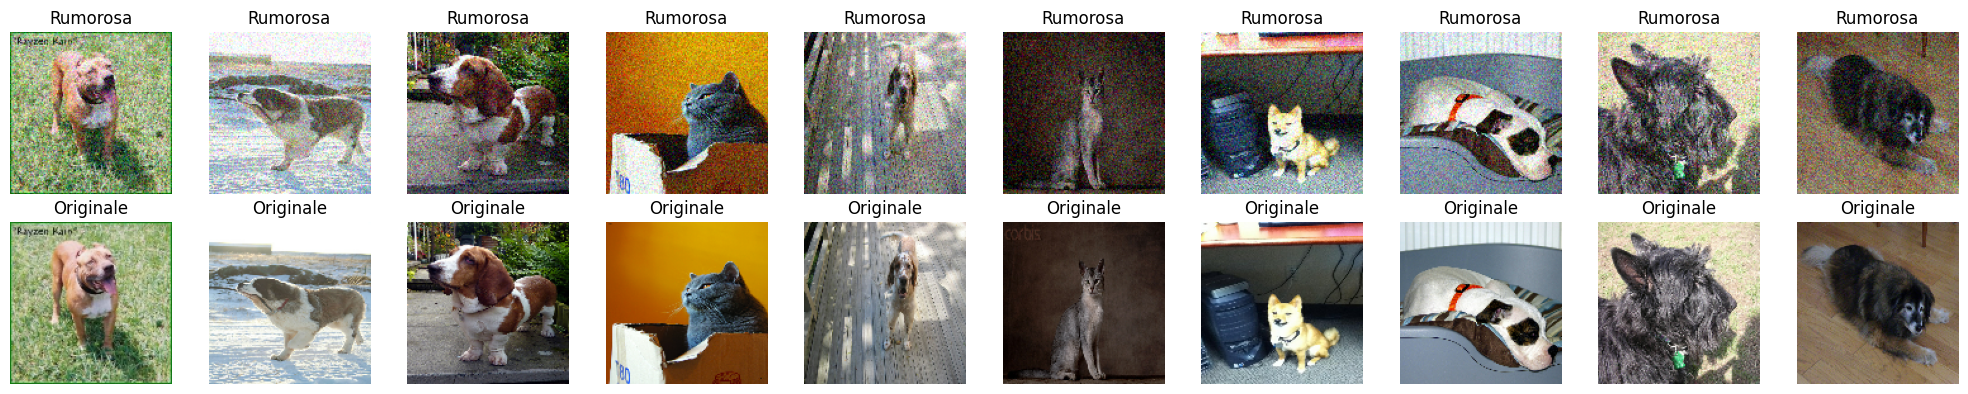

In [10]:
# Prendi un batch dal dataset (ad esempio, il primo batch)
batch = next(iter(valid_ds_noisy))
x_noisy_batch, x_original_batch = batch

# Converti i tensori in array NumPy
x_noisy_np_test = x_noisy_batch.numpy()
x_original_np_test = x_original_batch.numpy()

# Usa la funzione plot_side_by_side per visualizzare n immagini
plot_side_by_side(x_noisy_np_test, x_original_np_test, n=10)

Creazione modello

In [11]:
def plot_denoising_results(x_test_noisy, decoded_imgs, x_test, n=10):
    """
    Visualizza n immagini rumorose, le rispettive immagini denoised e quelle originali.
    """
    plt.figure(figsize=(20, 4))
    n = 10
    for i in range(n):
        # Immagine rumorosa
        ax = plt.subplot(3, n, i + 1)
        plt.imshow(x_test_noisy[i])
        plt.title("Rumorosa")
        plt.axis('off')
        # Immagine denoised
        ax = plt.subplot(3, n, i + 1 + n)
        plt.imshow(decoded_imgs[i])
        plt.title("Denoised")
        plt.axis('off')
        # Immagine originale
        ax = plt.subplot(3, n, i + 1 + 2*n)
        plt.imshow(x_test[i])
        plt.title("Originale")
        plt.axis('off')
    plt.tight_layout()
    plt.show()


In [12]:
def psnr(original, denoised):
  mse = np.mean((original - denoised) ** 2)
  if mse == 0:
    return float('inf') # immagini identiche
  max_pixel = 1.0 # valore massimo per immagini normalizzate in [0, 1]
  return 10 * np.log10((max_pixel ** 2) / mse)

In [13]:
def build_autoencoder(input_shape):
    """
    Costruisce un autoencoder convoluzionale per immagini a colori.
    Parametri:
      input_shape: forma dell'immagine in input (es. (32,32,3))
    Ritorna:
      autoencoder: modello compilato
    """
    input_img = Input(shape=input_shape)

    # Encoder
    x = Conv2D(64, (3,3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2,2), padding='same')(x)
    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2,2), padding='same')(x)

    # Decoder
    x = Conv2D(64, (3,3), activation='relu', padding='same')(encoded)
    x = UpSampling2D((2,2))(x)
    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = UpSampling2D((2,2))(x)
    decoded = Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

    autoencoder = Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='mse', metrics=['accuracy'])

    return autoencoder


def AutoEncoder(input_shape):
  input=Input(input_shape,name='Input')

  x=Conv2D(64, kernel_size=(3,3), kernel_initializer='he_normal', activation='relu', padding='same', name='Conv2d_1')(input)
  x=MaxPooling2D(name='Maxpool_1')(x)
  x=Conv2D(64,kernel_size=(3,3),kernel_initializer='he_normal',activation='relu',padding='same',name='Conv2d_2')(x)
  x=MaxPooling2D(name='Maxpool_2')(x)

  x=Conv2D(64,kernel_size=(3,3),kernel_initializer='he_normal',activation='relu',padding='same',name='Conv2d_3')(x)
  x=UpSampling2D(name='Upsample_1')(x)
  x=Conv2D(64,kernel_size=(3,3),kernel_initializer='he_normal',activation='relu',padding='same',name='Conv2d_4')(x)
  x=UpSampling2D(name='Upsample_2')(x)
  x=Conv2D(3,kernel_size=(3,3),kernel_initializer='he_normal',activation='relu',padding='same',name='Conv2d_5')(x)

  model=Model(input,x)
  model.compile(optimizer=tf.keras.optimizers.Adam(1e-03), loss=tf.keras.losses.MeanSquaredError(), metrics=['accuracy'])

  return model

def train_autoencoder(autoencoder, x_train_noisy, x_train, x_test_noisy, x_test, epochs=50, batch_size=128):
    """
    Addestra l'autoencoder utilizzando le immagini rumorose come input e quelle originali come target.
    """
    history = autoencoder.fit(x_train_noisy, x_train,
                              epochs=epochs,
                              batch_size=batch_size,
                              shuffle=True,
                              validation_data=(x_test_noisy, x_test))
    return history

In [14]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    ModelCheckpoint("best_autoen.keras", save_best_only=True)
]

In [15]:
autoencoder = build_autoencoder(input_shape=(img_size[0], img_size[1], 3))
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 3)    │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 114,307 (446.51 KB)

 Trainable params: 114,307 (446.51 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = autoencoder.fit(train_ds_noisy,
                validation_data=valid_ds_noisy,
                batch_size=batch_size,
                epochs=50,
                callbacks=callbacks)

Epoch 1/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 46s 309ms/step - accuracy: 0.5329 - loss: 0.0532 - val_accuracy: 0.5814 - val_loss: 0.0255
Epoch 2/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 34s 244ms/step - accuracy: 0.5804 - loss: 0.0233 - val_accuracy: 0.5945 - val_loss: 0.0174
Epoch 3/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 41s 243ms/step - accuracy: 0.5933 - loss: 0.0164 - val_accuracy: 0.6642 - val_loss: 0.0112
Epoch 4/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 40s 226ms/step - accuracy: 0.6673 - loss: 0.0103 - val_accuracy: 0.7187 - val_loss: 0.0116
Epoch 5/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 42s 248ms/step - accuracy: 0.7032 - loss: 0.0101 - val_accuracy: 0.7335 - val_loss: 0.0087
Epoch 6/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 34s 249ms/step - accuracy: 0.7225 - loss: 0.0089 - val_accuracy: 0.7027 - val_loss: 0.0085
Epoch 7/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 44s 310ms/step - accuracy: 0.7224 - loss: 0.0084 - val_accuracy: 0.7448 - val_loss: 0.0077
Epoch 8/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 34s 248ms/step - accuracy: 0.7292 - loss: 0.0080 - val_accu

Predict e grafici

In [17]:
decoded_imgs = autoencoder.predict(x_noisy_np_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step 


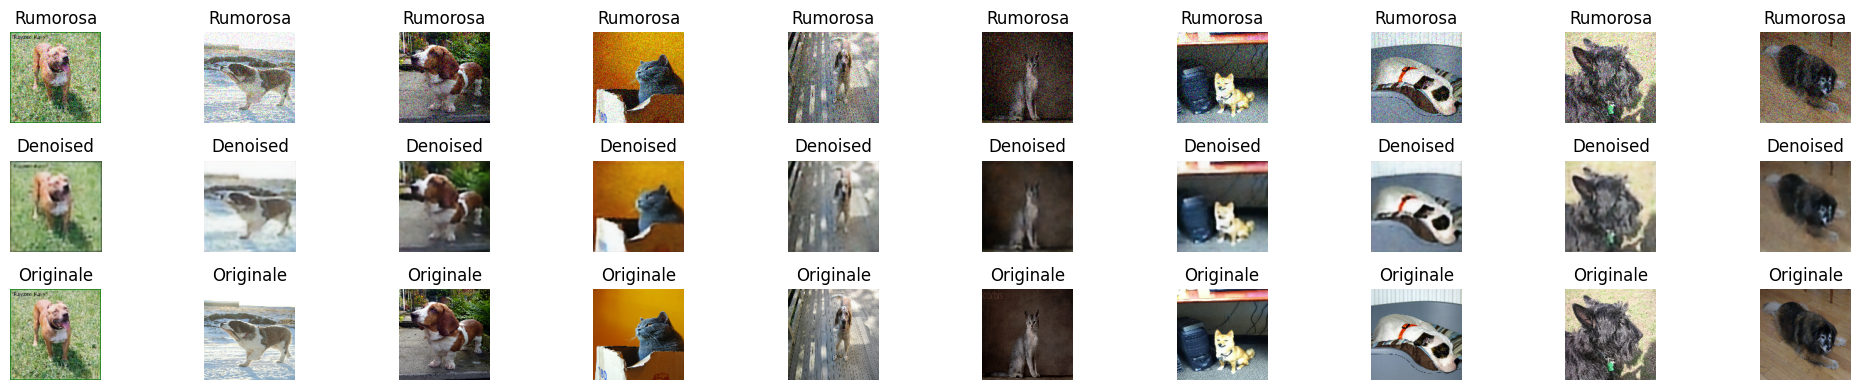

In [18]:
plot_denoising_results(x_noisy_np_test, decoded_imgs, x_original_np_test, n=10)

In [19]:
print(history.history.keys())  # mostra le chiavi disponibili

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [20]:
print(history.history['accuracy'])

[0.545417070388794, 0.5879970788955688, 0.6060265898704529, 0.6689512133598328, 0.7097522020339966, 0.7299527525901794, 0.7227162718772888, 0.7330992221832275, 0.7362576127052307, 0.7406461834907532, 0.7414076328277588, 0.7439624667167664, 0.7385668754577637, 0.7406586408615112, 0.744111180305481, 0.747761607170105, 0.7492514848709106, 0.7432377934455872, 0.7475587725639343, 0.746152937412262, 0.73710697889328, 0.7447861433029175, 0.7482995390892029, 0.7479511499404907, 0.7565027475357056, 0.7493184208869934, 0.7492794394493103, 0.752246081829071, 0.7508667707443237, 0.74998939037323, 0.7484991550445557, 0.7530635595321655, 0.7489330172538757, 0.7426357865333557, 0.7512702941894531, 0.752122700214386, 0.7517939209938049, 0.7506563067436218, 0.7519823312759399, 0.7503610849380493, 0.7437881827354431, 0.7526804208755493, 0.7520438432693481]


In [21]:
autoencoder.save('new_autoencoder.keras')

In [22]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(50)

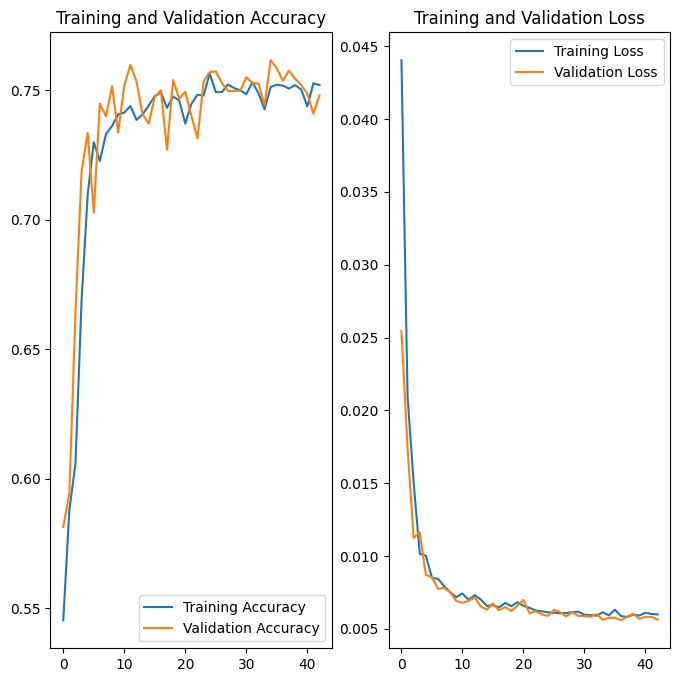

In [23]:
plt.figure(figsize=(8, 8))

# Get the actual number of epochs from the history
actual_epochs = len(history.history['accuracy'])
epochs_range = range(actual_epochs)


plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [24]:
from skimage.metrics import peak_signal_noise_ratio as psnr

In [25]:
def calculate_psnr(img1, img2):
    """
    Calcola il PSNR tra due immagini TensorFlow (img1 e img2).
    Entrambe devono essere float32 e normalizzate (0-1) o in uint8 (0-255).
    """
    return tf.image.psnr(img1, img2, max_val=1.0 if img1.dtype.is_floating else 255.0).numpy()


In [26]:
from collections import defaultdict

In [27]:
def psnr_by_noise_level(noisy_images, original_images, noise_levels):
    psnr_dict = defaultdict(list)

    for noisy, original, level in zip(noisy_images, original_images, noise_levels):
        psnr = calculate_psnr(tf.convert_to_tensor(noisy), tf.convert_to_tensor(original))
        psnr_dict[level].append(psnr)

    # Calcola media per ogni livello di rumore
    avg_psnr_by_level = {level: np.mean(values) for level, values in psnr_dict.items()}

    return avg_psnr_by_level

In [28]:
noise_levels = [0.1, 0.2, 0.3, 0.4]

In [29]:
def model_psnr_predict(model, original_images, noise_levels = [0.1, 0.2, 0.3, 0.4]):
  all_a_psnr = []
  for level in noise_levels:
    print("Noise level: " + str(level))
    noisy_images = original_images.map(lambda x, label: (add_noise_2(x, level), x))

    batch = next(iter(noisy_images))

    x_noisy_batch, x_original_batch = batch

    noisy_np = x_noisy_batch.numpy()
    original_np = x_original_batch.numpy()

    #Ridnet predict psnr
    decoded = model.predict(noisy_np)
    psnrs = [psnr(original_np[i], decoded[i], data_range=original_np[i].max() - original_np[i].min()) for i in range(len(decoded))]
    all_a_psnr.append(np.mean(psnrs))
    plot_denoising_results(noisy_np, decoded, original_np, n=10)
  print (all_a_psnr)
  return all_a_psnr

Noise level: 0.1
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


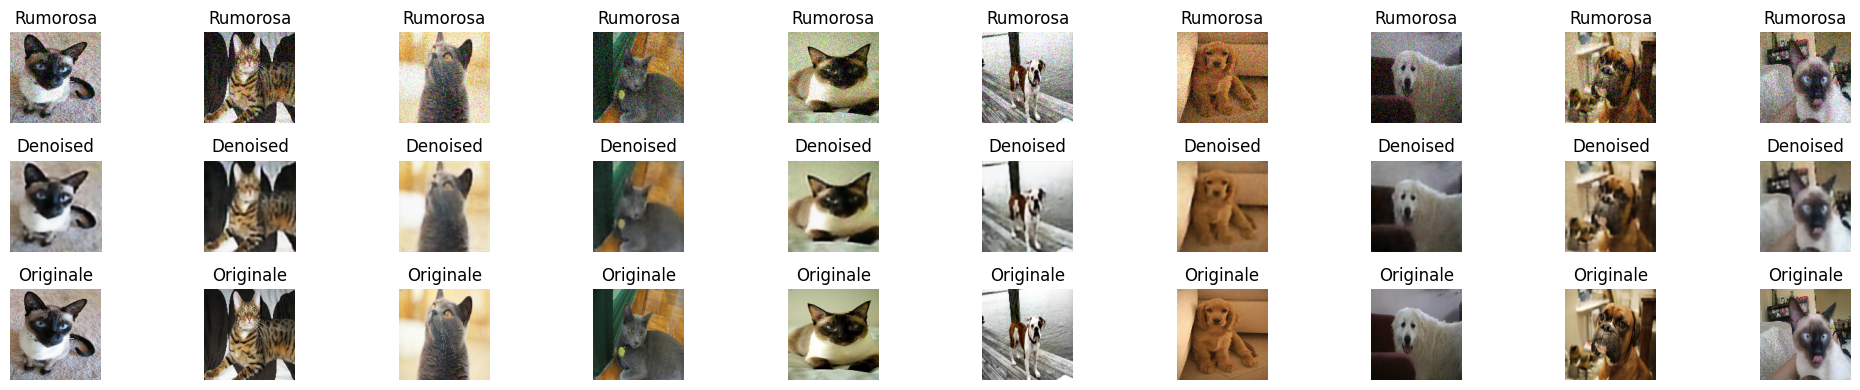

Noise level: 0.2
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


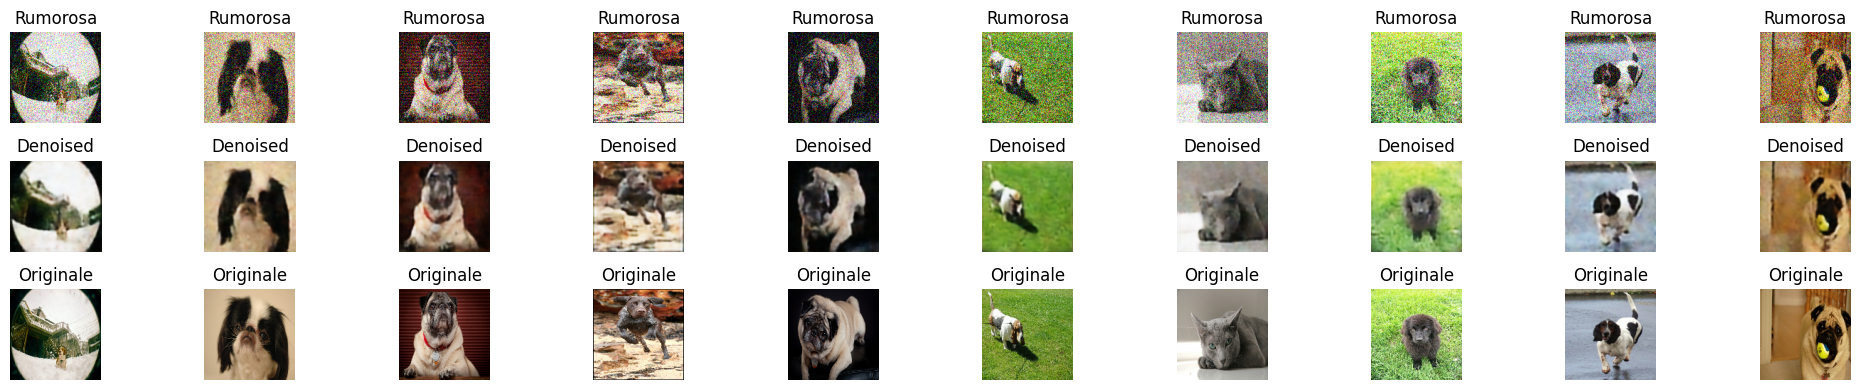

Noise level: 0.3
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


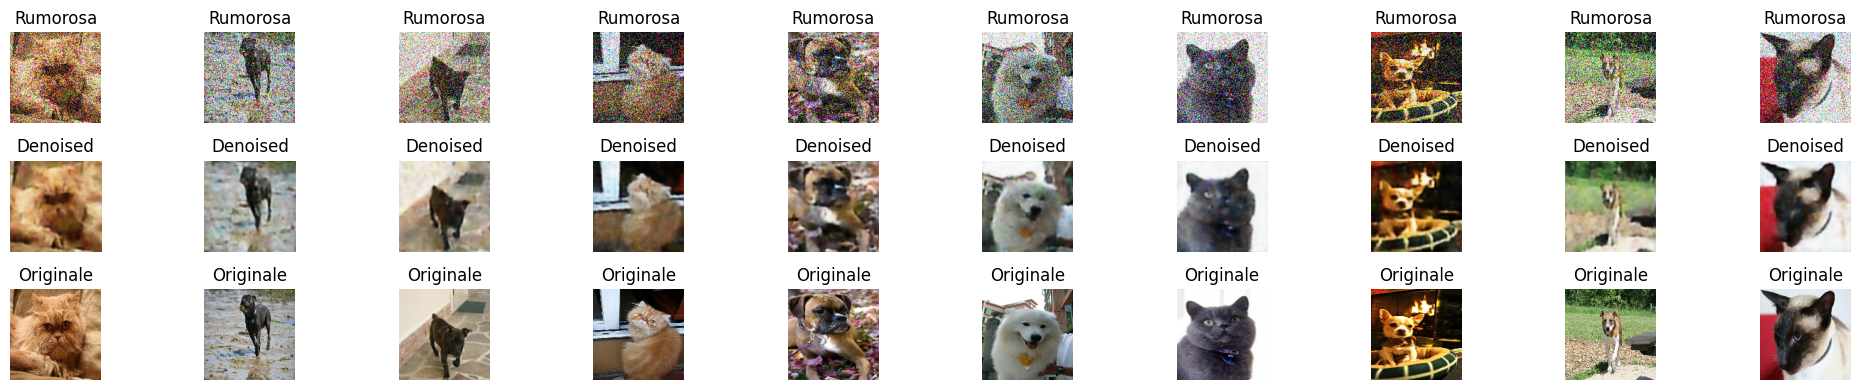

Noise level: 0.4
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


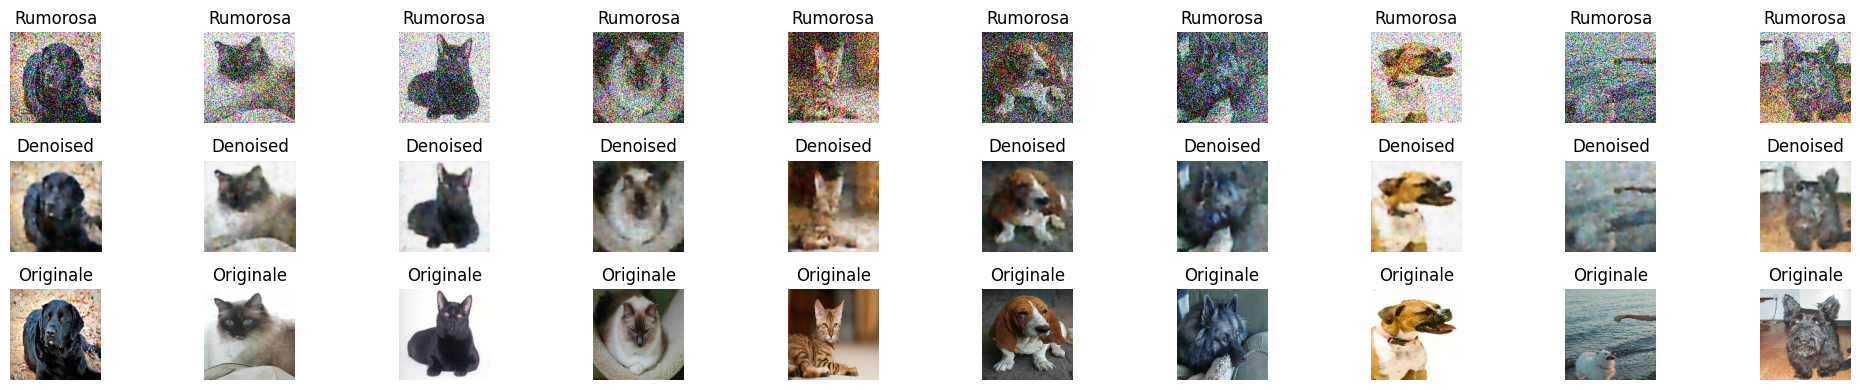

[np.float64(23.96985834368227), np.float64(22.754500778002733), np.float64(22.2109229100761), np.float64(21.7722564745891)]


In [30]:
all_autoen_psnr = model_psnr_predict(autoencoder, test_ds)

/tmp/ipython-input-31-2317759900.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


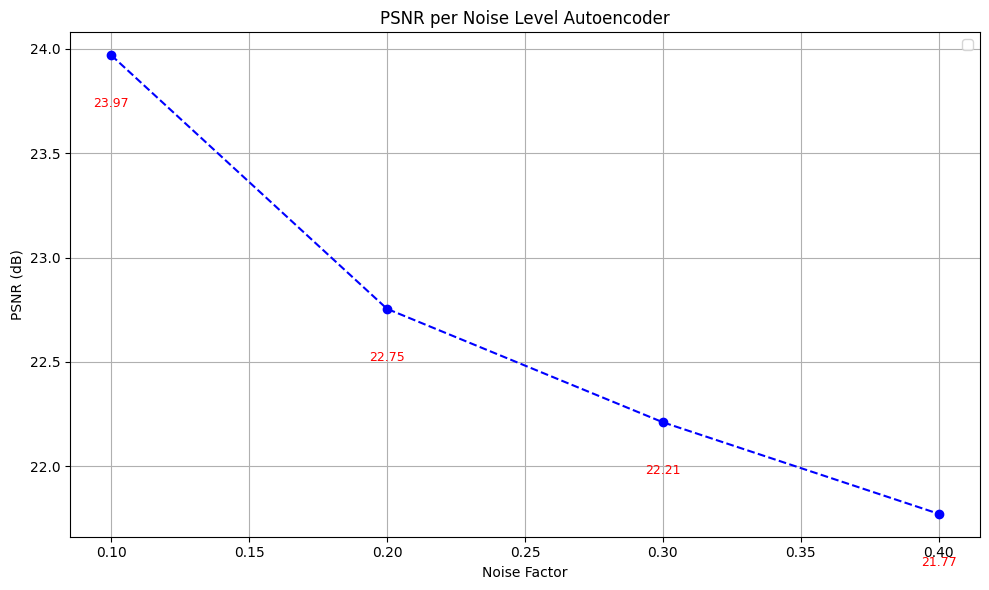

In [31]:
plt.figure(figsize=(10, 6))

plt.plot(noise_levels, all_autoen_psnr, marker='o', linestyle='--', color='b')
for x, y in zip(noise_levels, all_autoen_psnr):
    plt.text(x, y - 0.2, f"{y:.2f}", ha='center', va='top', fontsize=9, color='r')

plt.title("PSNR per Noise Level Autoencoder")
plt.xlabel("Noise Factor")
plt.ylabel("PSNR (dB)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
print(*[f"psnr: {val1}, noise: {val2}" for val1, val2 in zip(all_autoen_psnr, noise_levels)], sep='\n')


psnr: 23.96985834368227, noise: 0.1
psnr: 22.754500778002733, noise: 0.2
psnr: 22.2109229100761, noise: 0.3
psnr: 21.7722564745891, noise: 0.4


In [33]:
print(all_autoen_psnr, noise_levels)

[np.float64(23.96985834368227), np.float64(22.754500778002733), np.float64(22.2109229100761), np.float64(21.7722564745891)] [0.1, 0.2, 0.3, 0.4]
